In [13]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city
import matplotlib.pyplot as plt
import numpy as np

In [14]:
# Параметри алгоритму Шора
N = 15        # число, яке факторизуємо
a = 2         # число, взаємно просте з N
n = 4         # кількість кубітів у регістрі для пошуку періоду (2^n > N^2)

In [15]:
# Спрощена реалізація модульного піднесення до степеня
# Для N = 15 та a = 2 період r = 4 (навчальний приклад)
def modular_exponentiation(qc):
    qc.cx(0, 4)
    qc.cx(1, 5)
    qc.cx(2, 6)
    qc.cx(3, 7)
    return qc

# Квантова схема для statevector (без вимірювань)
# 4 кубіти для регістру x та 4 кубіти для регістру f(x)
qc_sv = QuantumCircuit(8)

# Підготовка суперпозиції всіх можливих значень x
qc_sv.h(range(4))

# Квантовий етап алгоритму Шора — модульне піднесення до степеня
qc_sv = modular_exponentiation(qc_sv)

# Отримання statevector
state = Statevector.from_instruction(qc_sv)
print("Statevector:\n", state)

# Візуалізація квантового стану
plot_state_city(state)
plt.show()

Statevector:
 Statevector([0.25+0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.25+0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.25+0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.25+0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.25+0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  

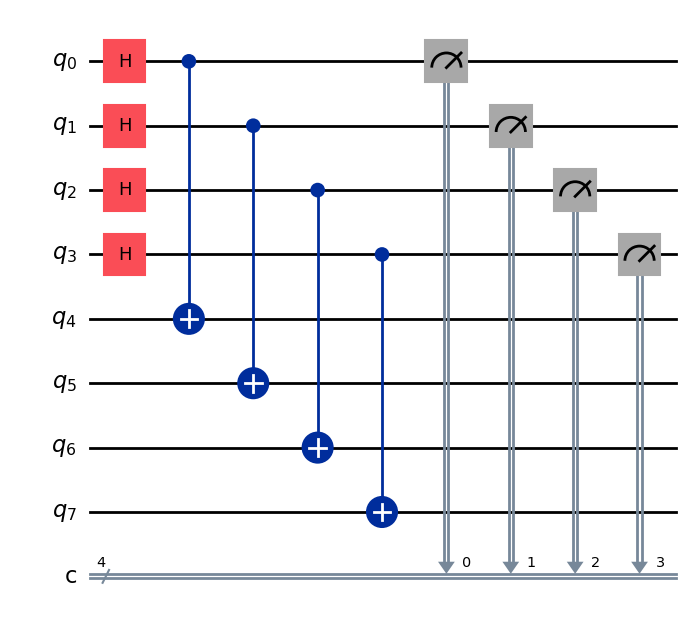

In [16]:
# Квантова схема з вимірюванням (QASM)
qc = QuantumCircuit(8, 4)

# Створення суперпозиції
qc.h(range(4))

# Застосування квантового оракула (модульна експонента)
qc = modular_exponentiation(qc)

# Вимірювання першого регістру
qc.measure(range(4), range(4))

# Візуалізація схеми
qc.draw('mpl')

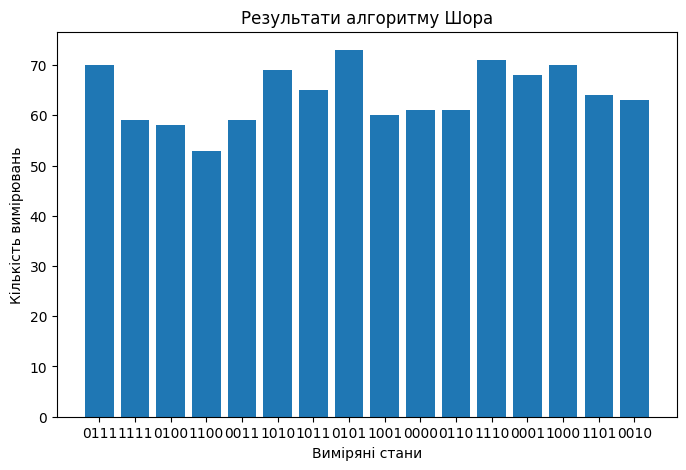

Counts: {'0111': 70, '1111': 59, '0100': 58, '1100': 53, '0011': 59, '1010': 69, '1011': 65, '0101': 73, '1001': 60, '0000': 61, '0110': 61, '1110': 71, '0001': 68, '1000': 70, '1101': 64, '0010': 63}
Виміряне значення k: 5
Відношення k / Q ≈ 0.3125
Знайдені дільники числа 15: 3 і 5


In [17]:
# Симуляція на QASM симуляторі
backend = AerSimulator()
compiled = transpile(qc, backend)
job = backend.run(compiled, shots=1024)
counts = job.result().get_counts()

# Побудова гістограми
states = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(8,5))
plt.bar(states, values)
plt.xlabel("Виміряні стани")
plt.ylabel("Кількість вимірювань")
plt.title("Результати алгоритму Шора")
plt.show()

# Виведення counts у консолі
print("Counts:", counts)

# Класична частина алгоритму Шора
# Отримуємо найбільш ймовірний результат вимірювання
measured = max(counts, key=counts.get)
k = int(measured, 2)
Q = 2**n

print(f"Виміряне значення k: {k}")
print(f"Відношення k / Q ≈ {k/Q}")

# Для даного прикладу період r відомий наперед (r = 4)
r = 4

# Обчислення дільників числа N
p = np.gcd(a**(r//2) - 1, N)
q = np.gcd(a**(r//2) + 1, N)

print(f"Знайдені дільники числа {N}: {p} і {q}")